In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#Load_Datasets
df = pd.read_csv("../data/student_data.csv")

View Dataset


In [16]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [19]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Data Cleaning

In [20]:
# Check Missing Values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [22]:
# Remove Missing values
df = df.dropna()

In [24]:
# Remove Duplicates
df = df.drop_duplicates()

In [29]:
# Create Engagement Score
df["Engagement_Score"] = df["Attendance"] * 0.4 + df["Exam_Score"] * 0.3 + df["Previous_Scores"] * 0.3

Attendance Analysis

In [30]:
print(df["Attendance"].mean())

80.02085293195358


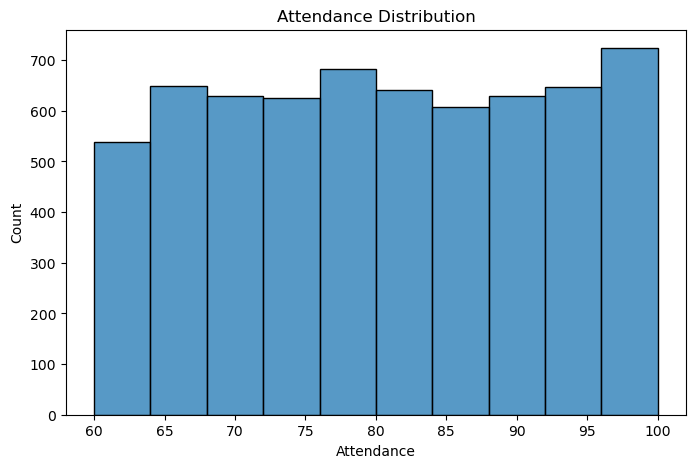

In [ ]:
# Attendance Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Attendance"], bins=10)
plt.title("Attendance Distribution")
plt.savefig("../visuals/attendance_distribution.png")
plt.show()

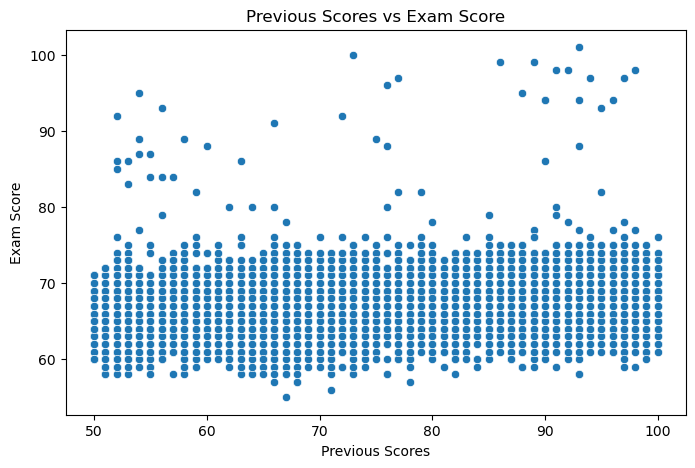

In [ ]:
# Previous Scores vs Exam Scores
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Previous_Scores"],
    y=df["Exam_Score"]
)
plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.savefig("../visuals/Previous_Scores_vs_Exam_Scores.png")
plt.show()

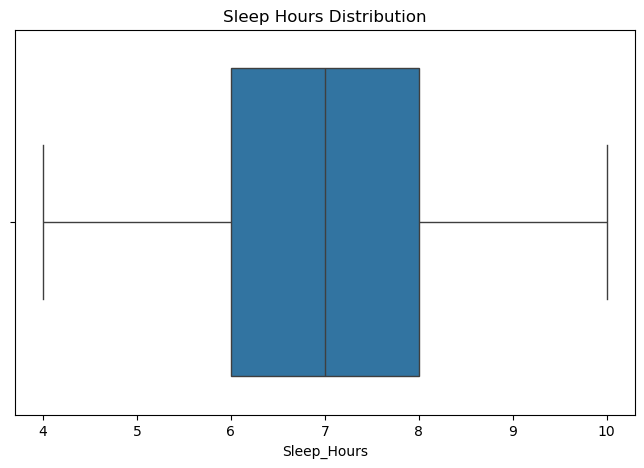

In [36]:
# Sleep Hours Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sleep_Hours"]
)

plt.title("Sleep Hours Distribution")
plt.show()

In [37]:
# Engagement Score 
df["Engagement_Score"] = (
    df["Attendance"] * 0.5 +
    df["Hours_Studied"] * 0.5
)

In [38]:
df[["Attendance","Hours_Studied","Engagement_Score"]].head()

,Attendance,Hours_Studied,Engagement_Score
0,84,23,53.5
1,64,19,41.5
2,98,24,61.0
3,89,29,59.0
4,92,19,55.5


In [44]:
df["Risk_Level"] = np.where(
    df["Exam_Score"] < 50,
    "High Risk",
    "Low Risk"
)

In [45]:
df["Risk_Level"].value_counts()


Risk_Level
Low Risk    6378
Name: count, dtype: int64

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
    ]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [43]:
# Select features 
X = df[[
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Engagement_Score"
]]

In [46]:
y = df["Risk_Level"]

In [47]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
# Prediction
predictions = model.predict(X_test)

In [50]:
# Model Accuracy
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:")
print(accuracy)

Model Accuracy:
1.0


In [51]:
# feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
0      Hours_Studied         0.0
1         Attendance         0.0
2        Sleep_Hours         0.0
3    Previous_Scores         0.0
4  Tutoring_Sessions         0.0
5  Physical_Activity         0.0
6   Engagement_Score         0.0


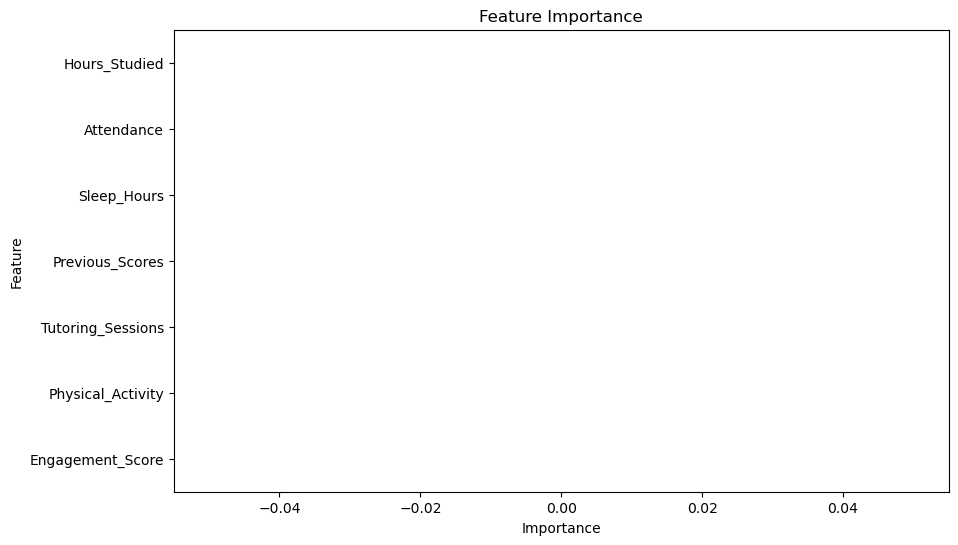

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=importance["Importance"],
    y=importance["Feature"]
)
plt.title("Feature Importance")
plt.savefig("../visuals/feature_importance.png")
plt.show()

In [53]:
df.to_csv(
    "../data/cleaned_student_data.csv",
    index=False
)

In [54]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Engagement_Score,Average_Marks,Risk_Level
0,23,84,1,0,0,7,73,1,1,0,...,2,3,0,1,2,1,67,53.5,70.0,Low Risk
1,19,64,1,2,0,8,59,1,1,2,...,0,4,0,0,1,0,61,41.5,60.0,Low Risk
2,24,98,2,2,1,7,91,2,1,2,...,1,4,0,2,2,1,74,61.0,82.5,Low Risk
3,29,89,1,2,1,8,98,2,1,1,...,0,4,0,1,1,1,71,59.0,84.5,Low Risk
4,19,92,2,2,1,6,65,2,1,3,...,1,4,0,0,2,0,70,55.5,67.5,Low Risk
